## **1) Monstruos en las 10 habitaciones con más comentarios bug**

```
[
  // Añade un campo nuevo "num_bug_comments" a cada habitación
  {
    $addFields: {
      num_bug_comments: {       // nombre del campo calculado
        $size: {                // cuenta cuántos elementos tiene el array resultante
          $filter: {
            input: "$hints",    // recorre el array hints de cada habitación
            as: "h",            // cada elemento lo llama "h"
            cond: { $eq: ["$$h.category", "bug"] }  // solo se queda con los que son "bug"
          }
        }
      }
    }
  },
  // Ordena de mayor a menor según el campo recién creado
  { $sort: { num_bug_comments: -1 } },
  // Se queda solo con las 10 primeras habitaciones
  { $limit: 10 },
  // Desdobla el array "monsters": cada monstruo pasa a ser un documento separado
  { $unwind: "$monsters" },
  // Agrupa por id de monstruo para eliminar duplicados
  {
    $group: {
      _id: "$monsters.id",              // clave de agrupación: id del monstruo
      name: { $first: "$monsters.name" } // se queda con el primer nombre que encuentra
    }
  },
  // Ordena los monstruos por su id de menor a mayor
  { $sort: { _id: 1 } },
  // Formatea la salida: quita _id y renombra el campo a idM
  {
    $project: {
      _id: 0,          // oculta el campo _id de MongoDB
      idM: "$_id",     // renombra _id a idM
      name: 1          // muestra el nombre
    }
  }
]
```

El **output** es:

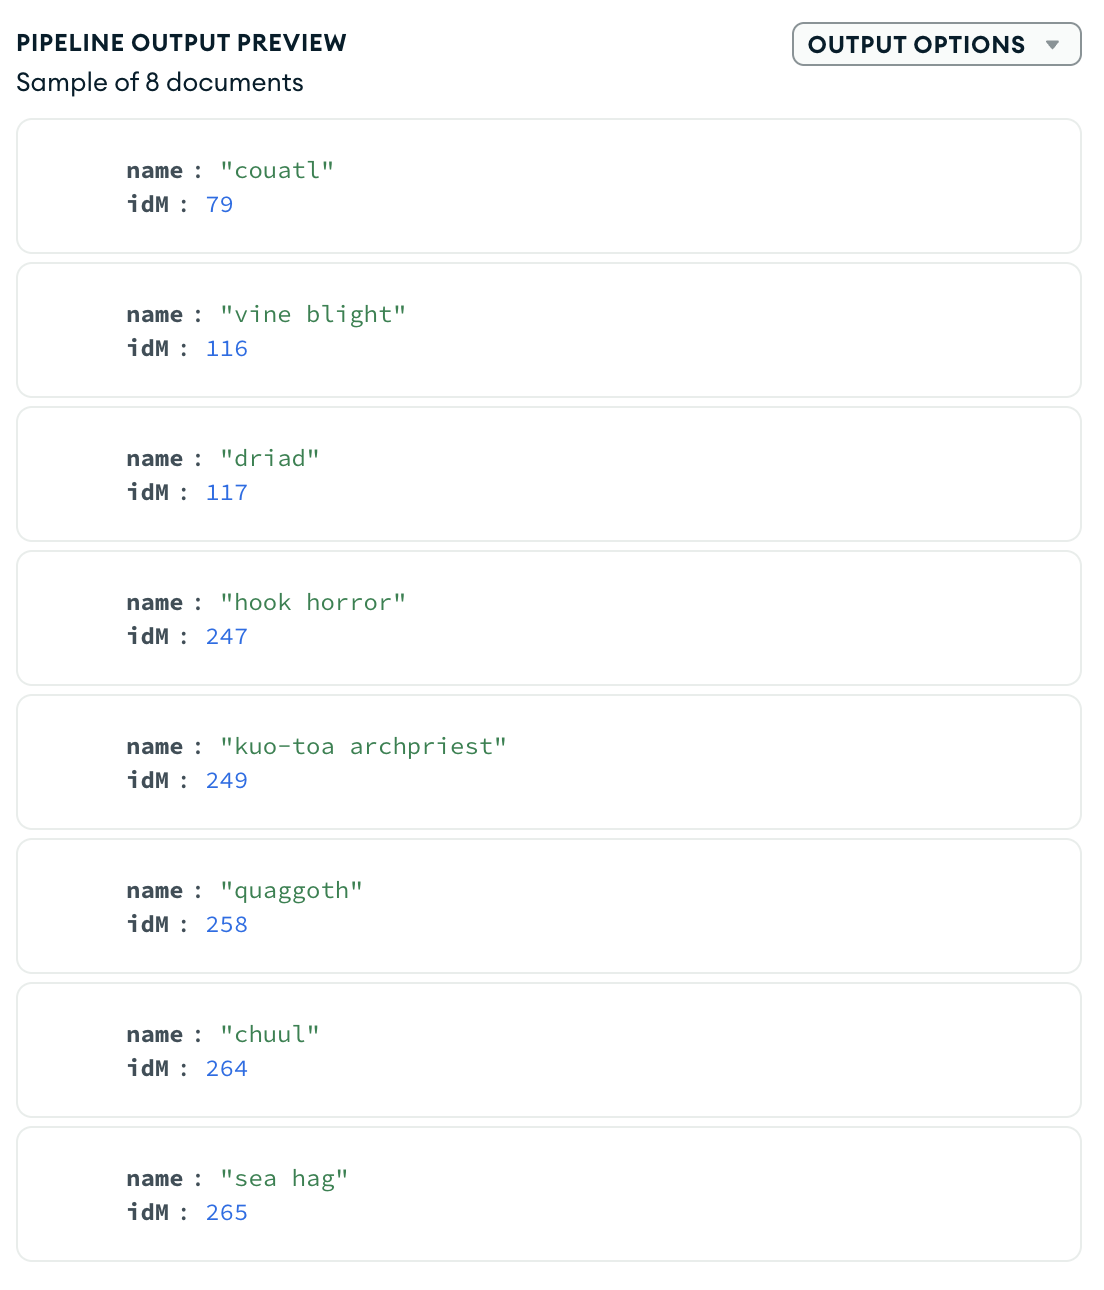

## **2) Mazmorras con comentarios hint por encima de la media**

```
[
  // Para cada habitación, calcula cuántos hints tiene de tipo "hint"
  {
    $project: {
      dungeon_id: 1,
      dungeon_name: 1,
      room_hint_count: {
        $size: {
          $filter: {
            input: "$hints",                          // recorre los hints
            as: "h",
            cond: { $eq: ["$$h.category", "hint"] }  // filtra solo los de tipo "hint"
          }
        }
      }
    }
  },
  // Agrupa por mazmorra y suma todos los hints de sus habitaciones
  {
    $group: {
      _id: { dungeon_id: "$dungeon_id", dungeon_name: "$dungeon_name" },
      hint_count: { $sum: "$room_hint_count" }  // total de hints por mazmorra
    }
  },
  // Segundo group con _id null: colapsa TODO en un único documento
  {
    $group: {
      _id: null,
      avg_hint_count: { $avg: "$hint_count" },  // calcula la media global
      dungeons: {
        $push: {                                  // guarda todas las mazmorras en un array
          dungeon_name: "$_id.dungeon_name",
          hint_count: "$hint_count"
        }
      }
    }
  },
  // Vuelve a separar el array de mazmorras en documentos individuales
  // (pero ahora cada uno tiene acceso al campo avg_hint_count del documento padre)
  { $unwind: "$dungeons" },
  // Filtra solo las mazmorras cuyo hint_count supera la media
  { $match: { $expr: { $gt: ["$dungeons.hint_count", "$avg_hint_count"] } } },
  // Muestra solo el nombre de la mazmorra
  {
    $project: {
      _id: 0,
      dungeon_name: "$dungeons.dungeon_name"
    }
  },
  // Ordena alfabéticamente
  { $sort: { dungeon_name: 1 } }
]
```

El **output** es:

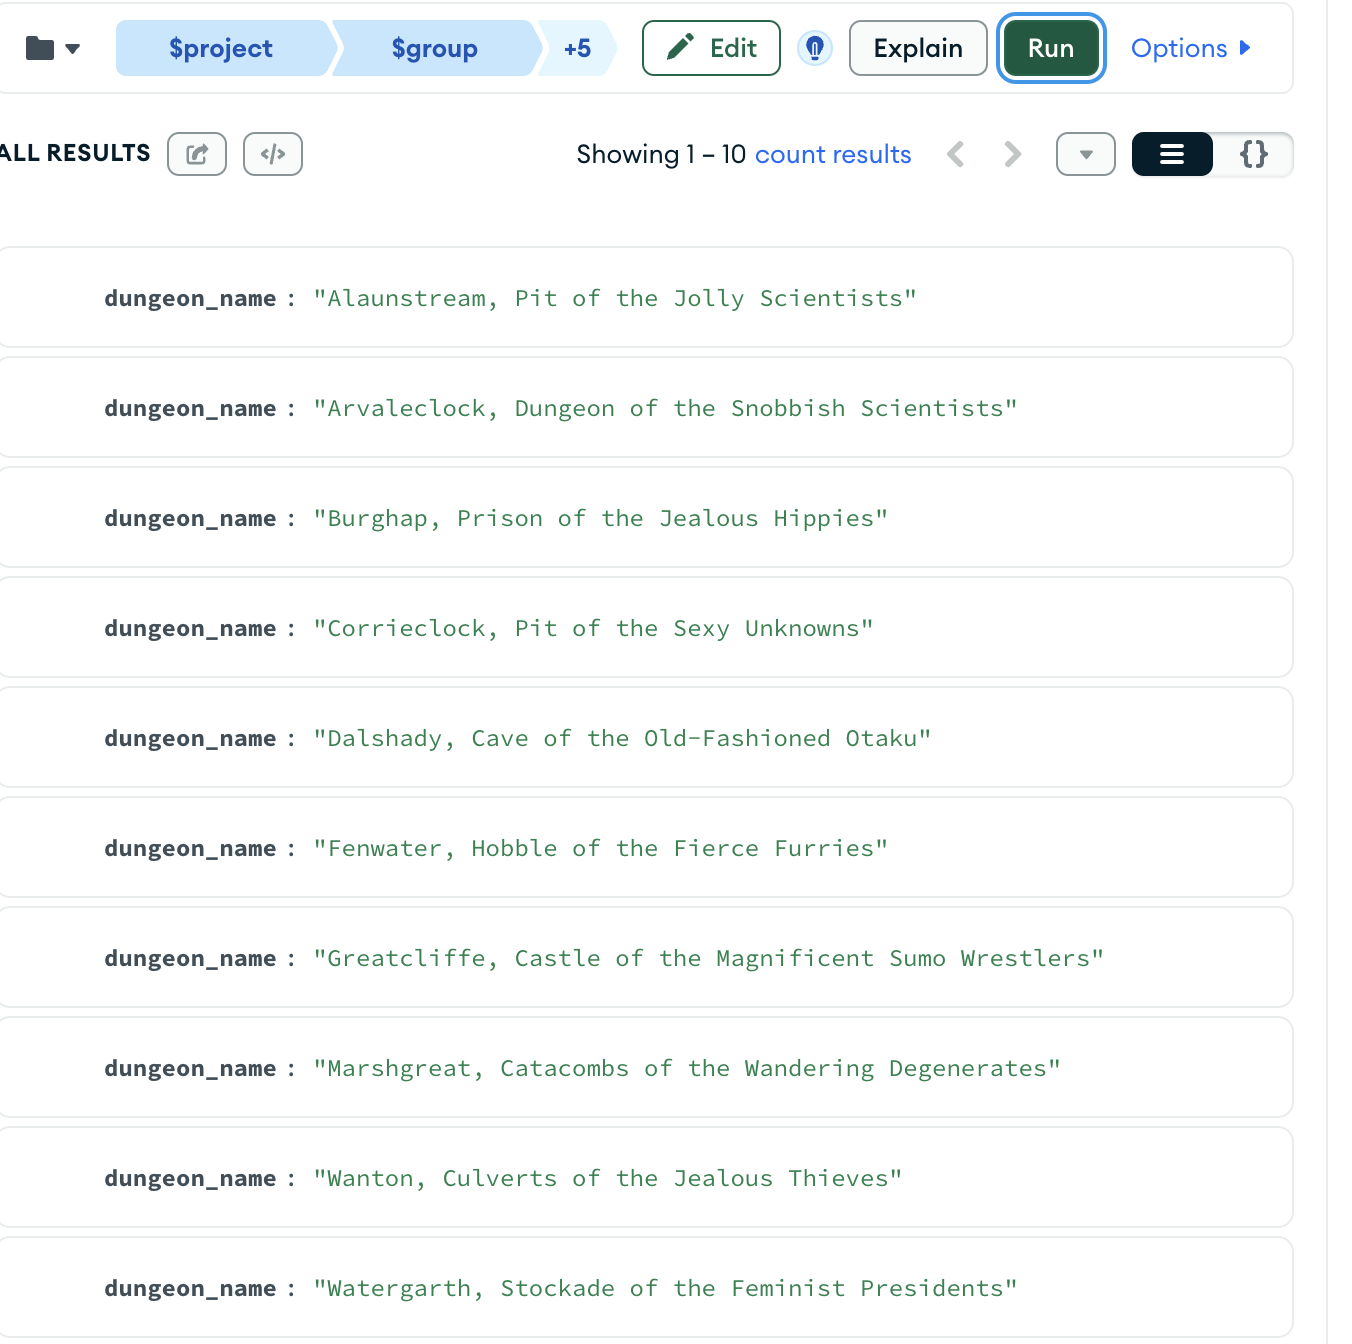

## **3) Por mazmorra: comentarios por tipo, oro total, nivel mediano y usuarios por país**